🚀 INITIATING SENIOR ML PIPELINE (ANTI-OVERFITTING MODE)...
📊 Training Data: 46 samples | Testing Data: 21 samples
🔐 Authenticating with MLflow Tracking Server...


2026/06/06 06:02:17 INFO mlflow.tracking.fluent: Experiment with name 'Sanitized_Dataset_HyperTuning' does not exist. Creating a new experiment.



⚙️ Tuning & Training: Ridge_Classifier...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
⭐ Best Params: {'clf__alpha': 1.0}
📊 CV Validation F1: 0.9520 | Test F1: 0.9527


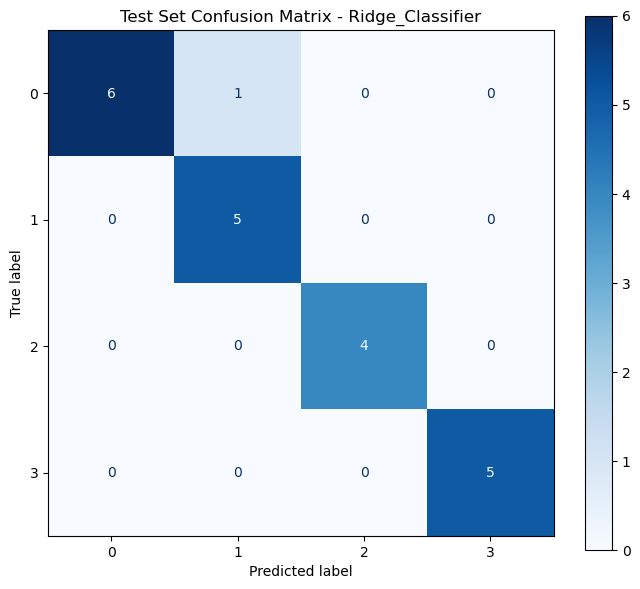

2026/06/06 06:02:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 06:02:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Ridge_Classifier_Master_Run at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5/runs/6b44c99ec6774c11a991de6c8c6de605
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5

⚙️ Tuning & Training: Logistic_Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
⭐ Best Params: {'clf__C': 0.5, 'clf__l1_ratio': 0.25}
📊 CV Validation F1: 0.9094 | Test F1: 0.9082


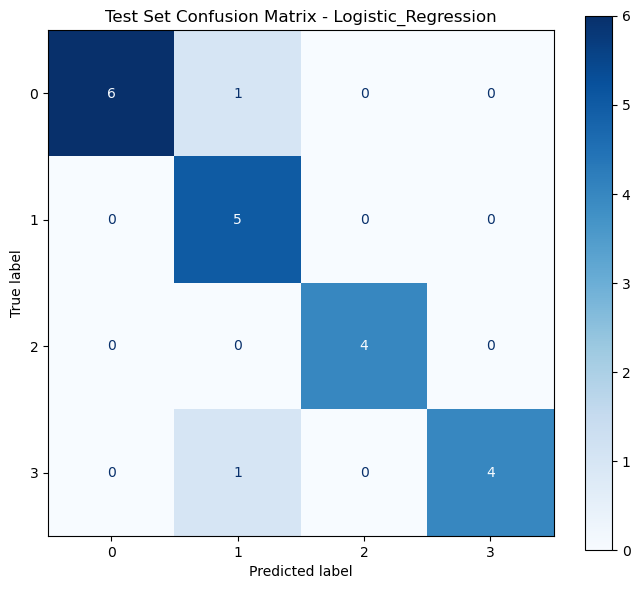

2026/06/06 06:02:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 06:02:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic_Regression_Master_Run at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5/runs/b1103acb8d3d4cb3bf1ca1d547571456
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5

⚙️ Tuning & Training: Random_Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
⭐ Best Params: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
📊 CV Validation F1: 0.8438 | Test F1: 0.8145


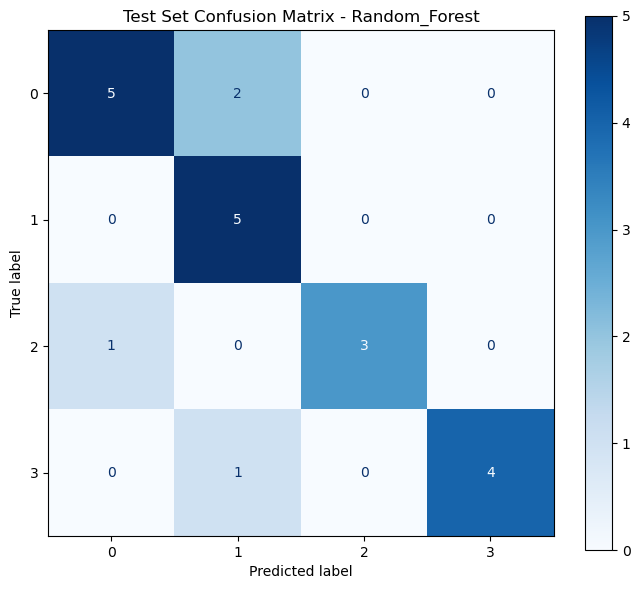

2026/06/06 06:02:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 06:03:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Random_Forest_Master_Run at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5/runs/f32b5c2cd3fb403d85750cc8b2bdb4e4
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5

⚙️ Tuning & Training: XGBoost...
Fitting 5 folds for each of 128 candidates, totalling 640 fits
⭐ Best Params: {'clf__colsample_bytree': 0.6, 'clf__learning_rate': 0.01, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.1, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.6}
📊 CV Validation F1: 0.8449 | Test F1: 0.8107


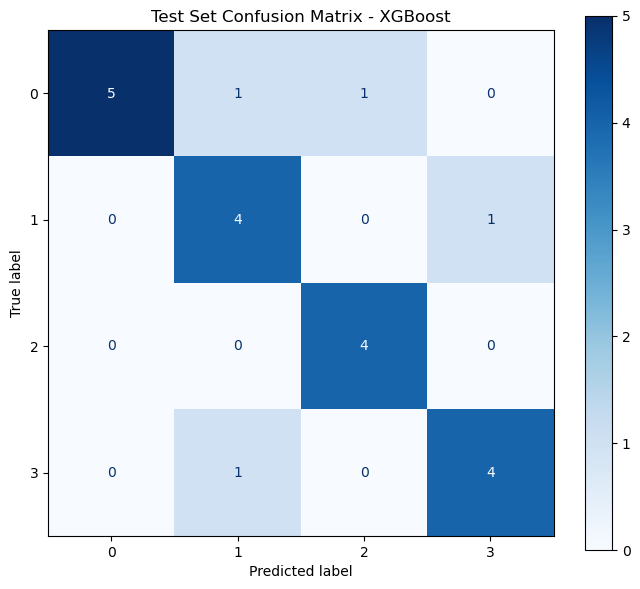

2026/06/06 06:03:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 06:03:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Master_Run at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5/runs/ca58225d6c634ec3972c3fade7262d7f
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/5

🏆 HYPERPARAMETER TUNING COMPLETE: FINAL LEADERBOARD
              Model  CV_Val_F1  Test_F1  Test_Accuracy
   Ridge_Classifier     0.9520   0.9527         0.9524
Logistic_Regression     0.9094   0.9082         0.9048
      Random_Forest     0.8438   0.8145         0.8095
            XGBoost     0.8449   0.8107         0.8095

✅ All parameters, strict CV metrics, Test metrics, Confusion Matrices, and Models are logged to DagsHub.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')

print("🚀 INITIATING SENIOR ML PIPELINE (ANTI-OVERFITTING MODE)...")

# ==========================================
# 1. DATA PREPARATION
# ==========================================
# Load the sanitized, leak-free dataset
df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/df_compression/Sanitized_Master_Dataset.csv')

# Separate Features (X) and Target (y)
X = df.drop(columns=['Code', 'Target_Crop_Grouped'])
y = df['Target_Crop_Grouped'].astype(int).values.ravel()

# 70/30 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"📊 Training Data: {X_train.shape[0]} samples | Testing Data: {X_test.shape[0]} samples")

# ==========================================
# 2. DAGSHUB / MLFLOW AUTHENTICATION
# ==========================================
print("🔐 Authenticating with MLflow Tracking Server...")
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME", "")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD", "")

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "file:./mlruns")
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("Sanitized_Dataset_HyperTuning")

# Disabled autologging to prevent DagsHub 403 rate-limit crashes.
# We will manually log everything precisely.
mlflow.autolog(disable=True)

# ==========================================
# 3. PIPELINES & ANTI-OVERFITTING GRIDS
# ==========================================
# Wrapping models in a Pipeline with StandardScaler PREVENTS DATA LEAKAGE 
# during cross-validation by scaling each fold independently.
pipelines = {
    'Ridge_Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(class_weight='balanced', random_state=42))
    ]),
    'Logistic_Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, class_weight='balanced', random_state=42))
    ]),
    'Random_Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1))
    ])
}

# The Hyperparameter Grids (Prefix 'clf__' targets the classifier step in the pipeline)
param_grids = {
    'Ridge_Classifier': {
        'clf__alpha': [0.1, 1.0, 10.0, 50.0, 100.0] # Massive penalty options
    },
    'Logistic_Regression': {
        'clf__C': [0.01, 0.1, 0.5, 1.0],            # Inverse regularization (smaller = stronger penalty)
        'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0] # Ridge vs Lasso balance
    },
    'Random_Forest': {
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [2, 3, 5],                 # Strict depth limit
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [2, 4],             # Forces leaves to contain multiple samples
        'clf__max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'clf__max_depth': [1, 2],                    # Decision Stumps to prevent memorization
        'clf__learning_rate': [0.01, 0.05],          # Slow learning
        'clf__n_estimators': [50, 100],
        'clf__subsample': [0.6, 0.8],                # Row sampling
        'clf__colsample_bytree': [0.6, 0.8],         # Column sampling
        'clf__reg_alpha': [0.1, 1.0],                # L1 Lasso penalty on weights
        'clf__reg_lambda': [1.0, 5.0]                # L2 Ridge penalty on weights
    }
}

# ==========================================
# 4. RIGOROUS METRICS & CROSS-VALIDATION
# ==========================================
# 'weighted' is mandatory for imbalanced multi-class target variables
scoring_metrics = {
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'balanced_acc': make_scorer(balanced_accuracy_score)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 5. TRAINING LOOP & MLFLOW LOGGING
# ==========================================
results_summary = []

for model_name in pipelines.keys():
    print(f"\n⚙️ Tuning & Training: {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=pipelines[model_name],
        param_grid=param_grids[model_name],
        cv=cv_strategy,
        scoring=scoring_metrics,
        refit='f1_weighted', # We optimize for the best F1 score
        return_train_score=True,
        n_jobs=-1,
        verbose=1
    )
    
    # Start MLflow Tracking
    with mlflow.start_run(run_name=f"{model_name}_Master_Run") as run:
        
        # Fit the Grid Search
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        best_idx = grid_search.best_index_
        best_params = grid_search.best_params_
        
        print(f"⭐ Best Params: {best_params}")
        
        # --- LOG 1: BEST PARAMETERS ---
        mlflow.log_params(best_params)
        
        # --- LOG 2: CROSS-VALIDATION (VAL) METRICS ---
        val_metrics = {
            "cv_val_f1": grid_search.cv_results_['mean_test_f1_weighted'][best_idx],
            "cv_val_accuracy": grid_search.cv_results_['mean_test_accuracy'][best_idx],
            "cv_val_precision": grid_search.cv_results_['mean_test_precision'][best_idx],
            "cv_val_recall": grid_search.cv_results_['mean_test_recall'][best_idx],
            "cv_val_balanced_acc": grid_search.cv_results_['mean_test_balanced_acc'][best_idx]
        }
        mlflow.log_metrics(val_metrics)
        
        # --- LOG 3: HOLDOUT TEST SET METRICS ---
        y_pred_test = best_model.predict(X_test)
        
        test_metrics = {
            "test_f1": f1_score(y_test, y_pred_test, average='weighted'),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
            "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
            "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
            "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
        }
        mlflow.log_metrics(test_metrics)
        
        print(f"📊 CV Validation F1: {val_metrics['cv_val_f1']:.4f} | Test F1: {test_metrics['test_f1']:.4f}")
        
        results_summary.append({
            'Model': model_name,
            'CV_Val_F1': val_metrics['cv_val_f1'],
            'Test_F1': test_metrics['test_f1'],
            'Test_Accuracy': test_metrics['test_accuracy']
        })
        
        # --- LOG 4: CONFUSION MATRIX IMAGE ---
        cm = confusion_matrix(y_test, y_pred_test)
        
        # Try extracting classes natively, fallback to unique y values
        try:
            classes = best_model.named_steps['clf'].classes_
        except AttributeError:
            classes = np.unique(y)
            
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d') 
        plt.title(f"Test Set Confusion Matrix - {model_name}")
        plt.tight_layout()
        
        # Save temp image, log to MLflow, and render for the user
        img_path = f"{model_name}_cm.png"
        plt.savefig(img_path, dpi=300)
        mlflow.log_artifact(img_path, "evaluation_plots")
        
        plt.show()
        
        # Clean up local image file
        if os.path.exists(img_path):
            os.remove(img_path)
            
        # --- LOG 5: SAVE THE FINAL MODEL ---
        mlflow.sklearn.log_model(best_model, f"{model_name}_model")

# ==========================================
# 6. FINAL LEADERBOARD
# ==========================================
df_summary = pd.DataFrame(results_summary).sort_values(by='Test_F1', ascending=False)
print("\n🏆 HYPERPARAMETER TUNING COMPLETE: FINAL LEADERBOARD")
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n✅ All parameters, strict CV metrics, Test metrics, Confusion Matrices, and Models are logged to DagsHub.")